# Data Augmentations Report

This notebook visualizes how each augmentation in `src/augmentations/LightCurveTransform.py` modifies a real sample from the H5 dataset.

**H5 schema recap**
- `flux`  — magnitude readings, shape `(N, seqlen, bands)`
- `time`  — observation times, shape `(N, seqlen, bands)`
- `mask`  — 1 = real reading, 0 = padding, shape `(N, seqlen, bands)`

Augmentations operate on a single sample dict with keys `data`, `time`, `mask` (note: `data` ↔ `flux`).

In [1]:
import numpy as np
import h5py
import torch
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from src.augmentations.LightCurveTransform import (
    Roll,
    ZScoreUndersample,
    BandPermute,
    RandomMaskTimeVector,
    RandomMaskDataVector,
    RandomMaskMaskVector,
    WindowSelect,
    BlockWindow,
    MAXWindowSelect,
    RandomSubsample,
)

H5_PATH = '/home/magdalena/Desktop/sambashare/H5_files/2019/200_2019.h5'
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# Load one sample
with h5py.File(H5_PATH, 'r') as f:
    print('keys:', list(f.keys()))
    i = np.random.randint(0, 10000)
    flux = f['flux'][i]
    time = f['time'][i]
    mask = f['mask'][i]

print(f'sample idx {i}  |  shapes: flux={flux.shape}  time={time.shape}  mask={mask.shape}')
SEQLEN, NUM_BANDS = flux.shape
print(f'seqlen={SEQLEN}, num_bands={NUM_BANDS}')

keys: ['extracted_features', 'flux', 'flux_err', 'mask', 'mask_detection', 'mask_photometry', 'metadata_feat', 'oid', 'time', 'training_0', 'training_1', 'training_2', 'training_3', 'training_4', 'validation_0', 'validation_1', 'validation_2', 'validation_3', 'validation_4']
sample idx 2732  |  shapes: flux=(200, 2)  time=(200, 2)  mask=(200, 2)
seqlen=200, num_bands=2


In [3]:
def make_sample():
    """Fresh sample dict (augmentations mutate in place)."""
    return {
        'data': torch.from_numpy(flux).float().clone(),
        'time': torch.from_numpy(time).float().clone(),
        'mask': torch.from_numpy(mask).float().clone(),
        'labels': 0,
    }

def show(sample, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.heatmap(sample['data'].numpy(), ax=axes[0], cbar=False); axes[0].set_title(f'{title} — flux/data')
    sns.heatmap(sample['time'].numpy(), ax=axes[1], cbar=False); axes[1].set_title(f'{title} — time')
    sns.heatmap(sample['mask'].numpy().astype(float), ax=axes[2], cbar=False); axes[2].set_title(f'{title} — mask')
    for ax in axes:
        ax.set_xlabel('band'); ax.set_ylabel('seq')
    plt.tight_layout(); plt.show()

def summarize(sample):
    d, m = sample['data'], sample['mask']
    nz_per_band = [int((d[:, b] != 0).sum()) for b in range(d.shape[1])]
    print(f"  nonzero flux per band: {nz_per_band}  |  mask sum per band: {[int(m[:, b].sum()) for b in range(m.shape[1])]}")

## Baseline (no augmentation)

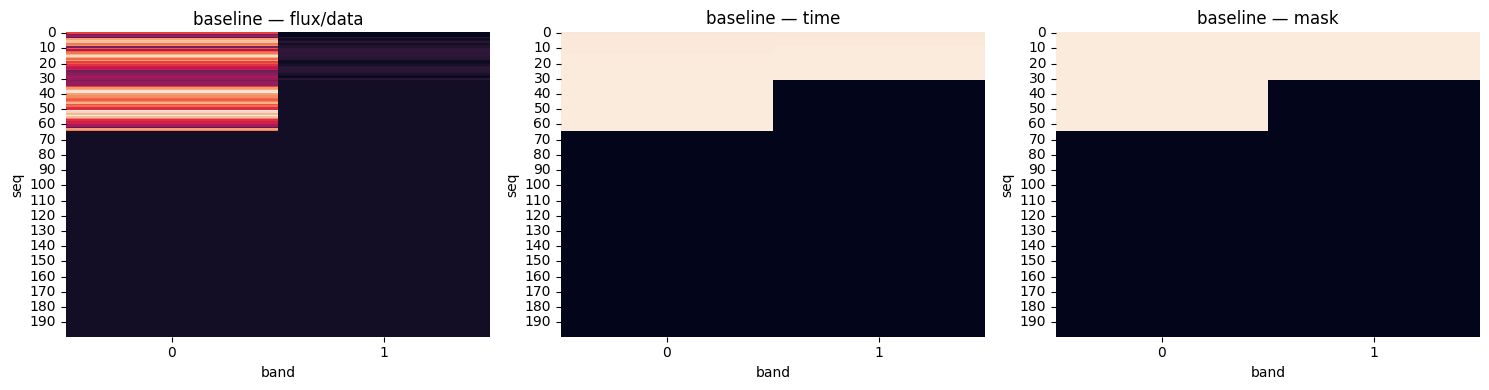

  nonzero flux per band: [65, 31]  |  mask sum per band: [65, 31]


In [4]:
base = make_sample(); show(base, 'baseline'); summarize(base)

## `Roll` — per-band circular shift along the time axis
Each band is rolled independently by a random int in `[0, max_roll)`. Preserves number of nonzero points; just reorders them in the sequence slot.

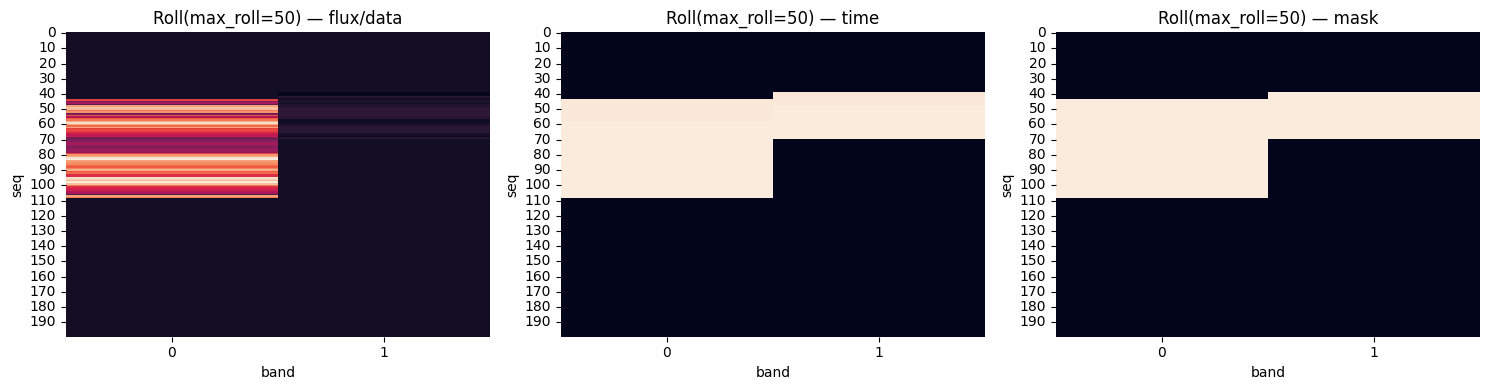

  nonzero flux per band: [65, 31]  |  mask sum per band: [65, 31]


In [5]:
aug = Roll(num_bands=NUM_BANDS, max_roll=50)
s = aug(make_sample()); show(s, 'Roll(max_roll=50)'); summarize(s)

## `ZScoreUndersample` — keep only `|z| > thr` points
Selects high-deviation measurements per band, pads to `impose_seqlen`. Falls back to the original sample if too few points remain. When `thr=None` a random threshold in `[0,1)` is drawn each call.

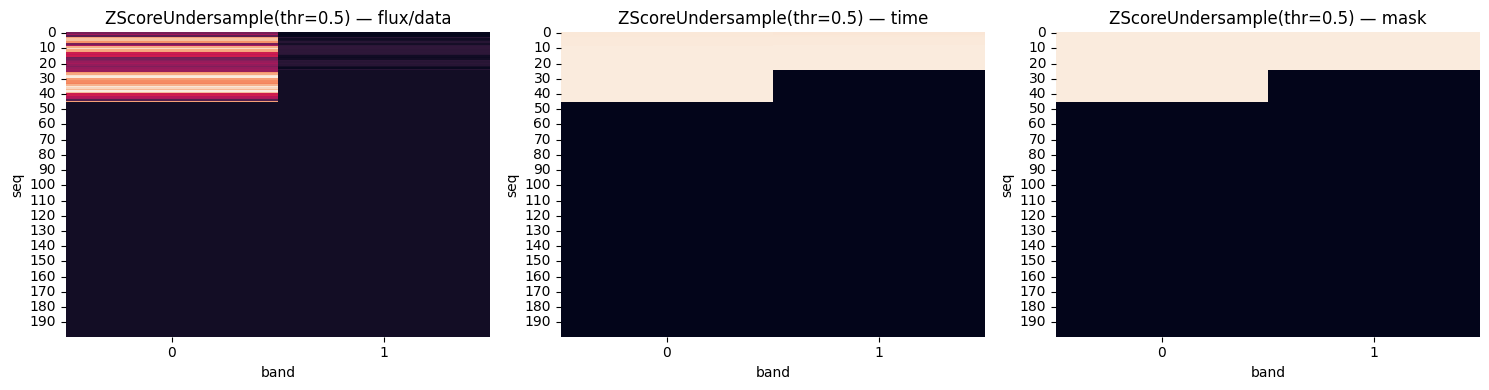

  nonzero flux per band: [46, 25]  |  mask sum per band: [46, 25]


In [6]:
aug = ZScoreUndersample(thr=0.5, impose_seqlen=SEQLEN)
s = aug(make_sample()); show(s, 'ZScoreUndersample(thr=0.5)'); summarize(s)

## `BandPermute` — circular roll along the band axis
Reorders the bands (columns) by a random shift. Useful for breaking band-specific biases.

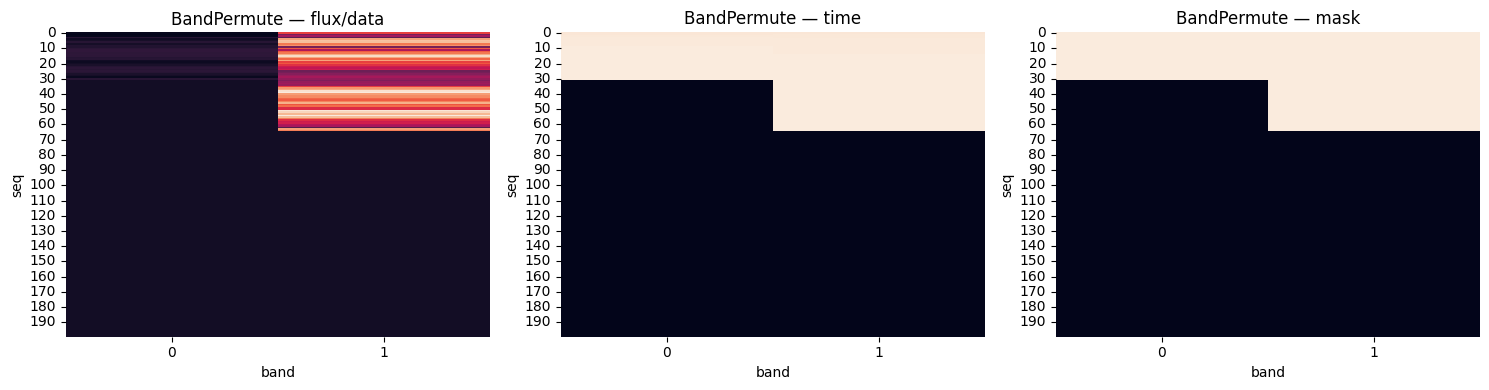

  nonzero flux per band: [31, 65]  |  mask sum per band: [31, 65]


In [7]:
aug = BandPermute(num_bands=NUM_BANDS)
s = aug(make_sample()); show(s, 'BandPermute'); summarize(s)

## `RandomMaskTimeVector` — zero out time entries with prob `p`
Only the `time` channel is perturbed. `data` and `mask` are untouched, so there is no visible change in the flux/mask heatmaps.

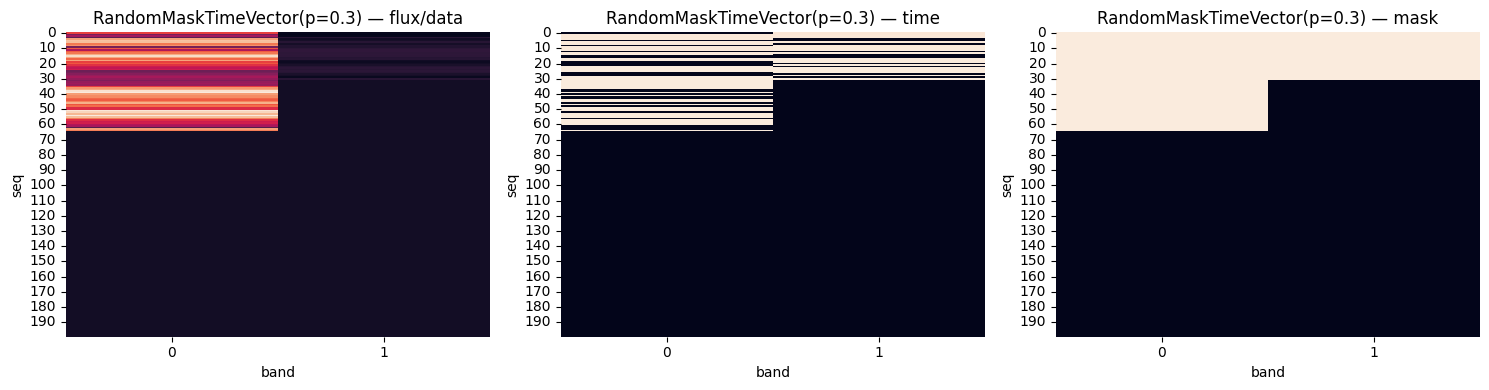

  nonzero flux per band: [65, 31]  |  mask sum per band: [65, 31]


In [8]:
aug = RandomMaskTimeVector(num_bands=NUM_BANDS, p=0.3)
s = aug(make_sample()); show(s, 'RandomMaskTimeVector(p=0.3)'); summarize(s)

## `RandomMaskDataVector` — zero out flux entries with prob `p`
Drops readings from `data` while leaving `time` and `mask` in place (mask becomes inconsistent with data — intentional for SSL).

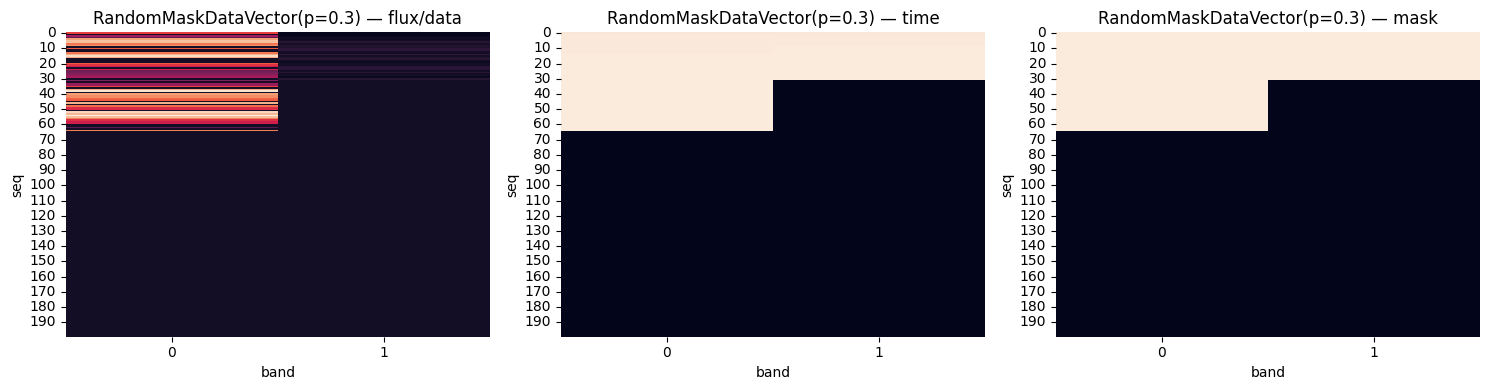

  nonzero flux per band: [47, 20]  |  mask sum per band: [65, 31]


In [9]:
aug = RandomMaskDataVector(num_bands=NUM_BANDS, p=0.3)
s = aug(make_sample()); show(s, 'RandomMaskDataVector(p=0.3)'); summarize(s)

## `RandomMaskMaskVector` — zero out mask entries with prob `p`
Flips `mask` → 0 at random positions, hiding valid measurements from downstream attention without removing the underlying data.

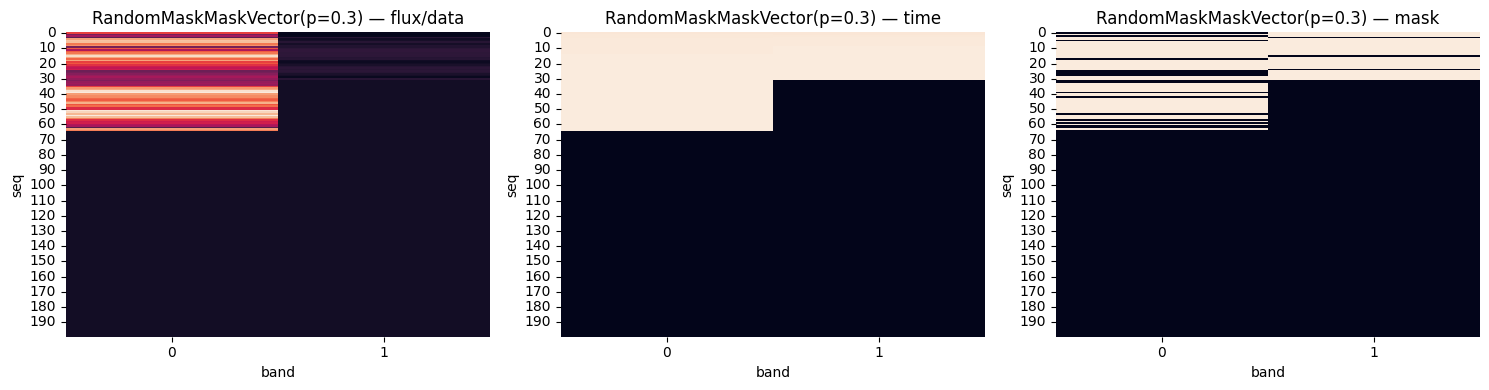

  nonzero flux per band: [65, 31]  |  mask sum per band: [47, 28]


In [10]:
aug = RandomMaskMaskVector(num_bands=NUM_BANDS, p=0.3)
s = aug(make_sample()); show(s, 'RandomMaskMaskVector(p=0.3)'); summarize(s)

## `WindowSelect` — keep a random contiguous window of nonzero points
Per-band random start index over nonzero measurements. Kept points are rolled to the start of the sequence; everything else is zeroed.

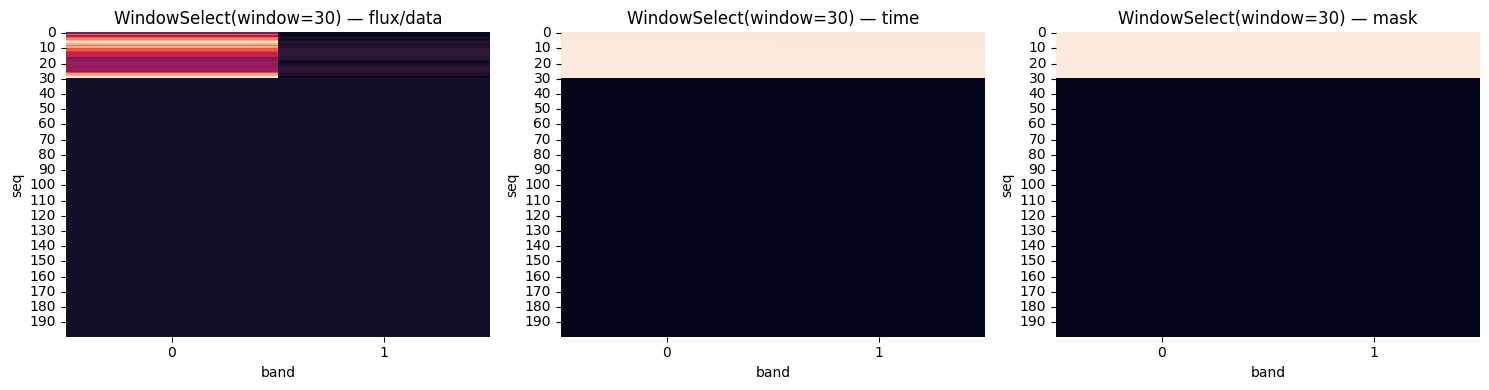

  nonzero flux per band: [30, 30]  |  mask sum per band: [30, 30]


In [11]:
aug = WindowSelect(num_bands=NUM_BANDS, window_size=30)
s = aug(make_sample()); show(s, 'WindowSelect(window=30)'); summarize(s)

## `BlockWindow` — zero out a contiguous block (inverse of WindowSelect)
Drops a random contiguous block of `window_size` nonzero measurements per band; the rest is kept in place.

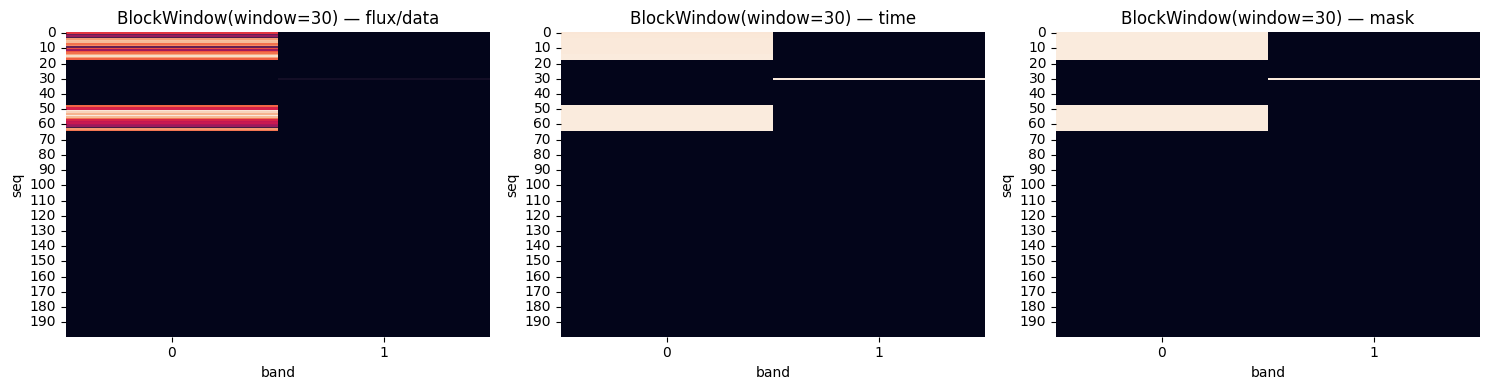

  nonzero flux per band: [35, 1]  |  mask sum per band: [35, 1]


In [12]:
aug = BlockWindow(num_bands=NUM_BANDS, window_size=30)
s = aug(make_sample()); show(s, 'BlockWindow(window=30)'); summarize(s)

## `MAXWindowSelect` — window centered on the max |flux|
Deterministic per band: centers a `window_size` window on the strongest measurement, rolls it to index 0.

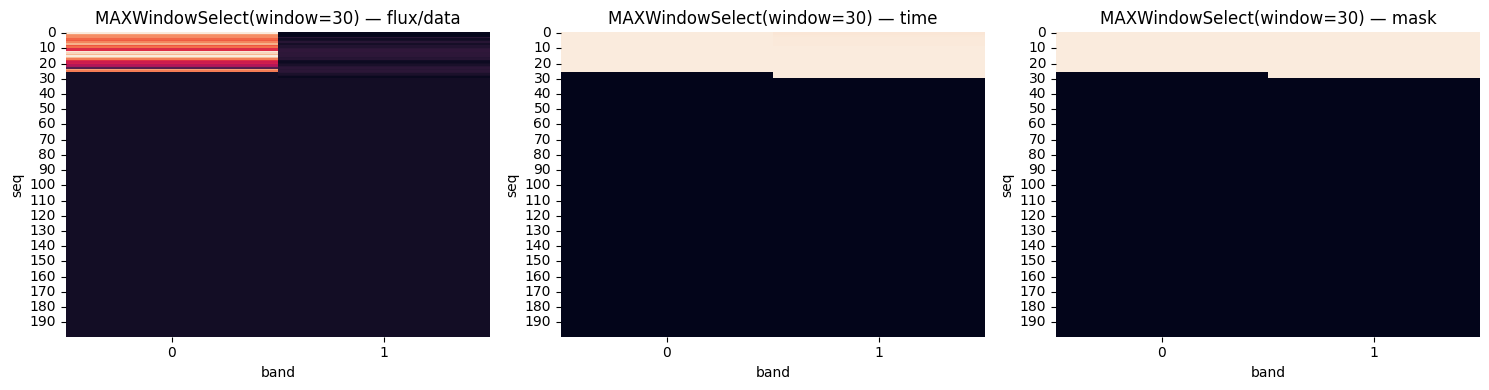

  nonzero flux per band: [26, 30]  |  mask sum per band: [26, 30]


In [13]:
aug = MAXWindowSelect(num_bands=NUM_BANDS, window_size=30)
s = aug(make_sample()); show(s, 'MAXWindowSelect(window=30)'); summarize(s)

## `RandomSubsample` — keep `window_size` random nonzero points (sorted)
Unlike `WindowSelect`, sampled indices are not contiguous; order is preserved by sorting.

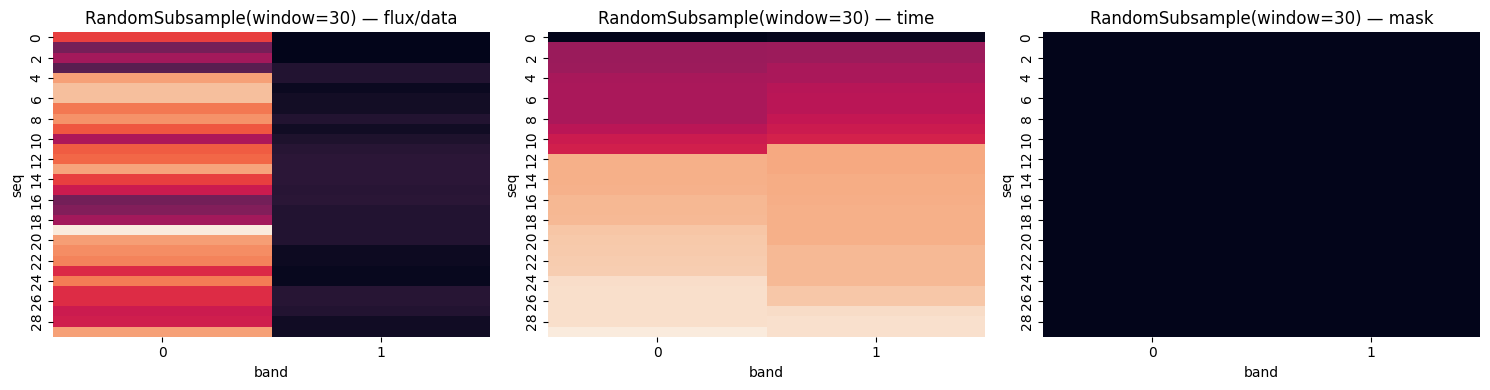

  nonzero flux per band: [30, 30]  |  mask sum per band: [30, 30]


In [14]:
aug = RandomSubsample(num_bands=NUM_BANDS, window_size=30)
s = aug(make_sample()); show(s, 'RandomSubsample(window=30)'); summarize(s)

## Summary

| Augmentation | Affects `data` | Affects `time` | Affects `mask` | Nonzero count |
|---|---|---|---|---|
| Roll | ✓ (shift) | ✓ (shift) | ✓ (shift) | preserved |
| ZScoreUndersample | ✓ | ✓ | ✓ (recomputed) | ≤ original |
| BandPermute | ✓ (band) | ✓ (band) | ✓ (band) | preserved |
| RandomMaskTimeVector | — | ✓ | — | preserved |
| RandomMaskDataVector | ✓ | — | — | reduced |
| RandomMaskMaskVector | — | — | ✓ | preserved (data-wise) |
| WindowSelect | ✓ | ✓ | ✓ | ≤ window_size |
| BlockWindow | ✓ | ✓ | ✓ | reduced by block |
| MAXWindowSelect | ✓ | ✓ | ✓ | ≤ window_size, peak-centered |
| RandomSubsample | ✓ | ✓ | ✓ | ≤ window_size (non-contiguous) |